# 05 - Local Decision Confidence Maps (LDCM)

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.config import FIGURES_DIR
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

# 
df = pd.read_csv("../data/test_points_with_sdr.csv")

if 'longitude' not in df.columns or 'latitude' not in df.columns:
    X_test = pd.read_csv("../data/processed/X_test.csv")
    df['longitude'] = X_test.loc[df['index'], 'longitude'].values
    df['latitude'] = X_test.loc[df['index'], 'latitude'].values


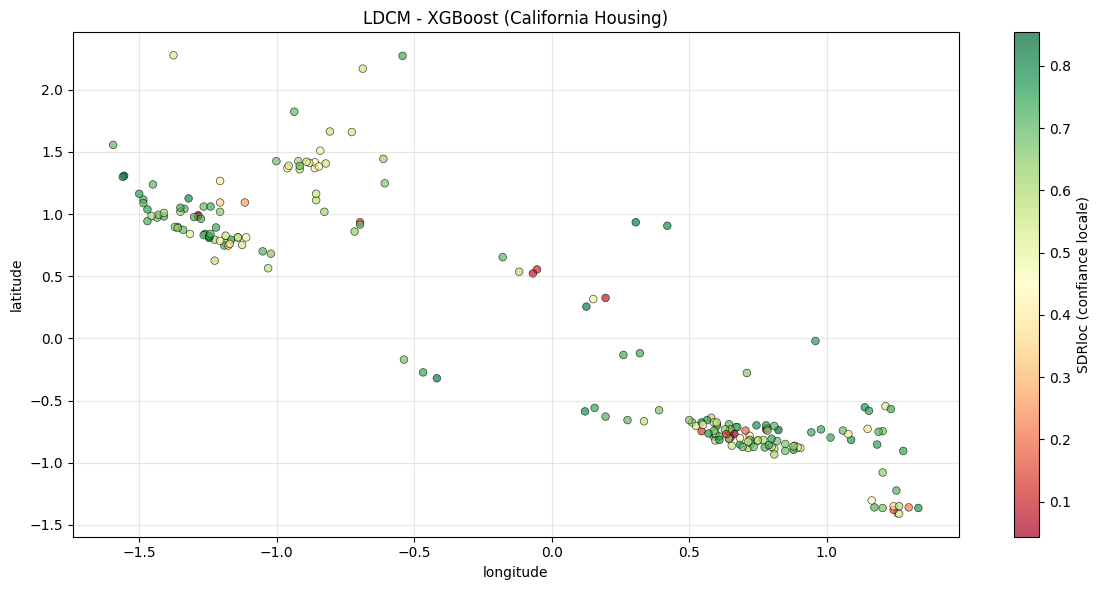

In [2]:
plt.figure(figsize=(12,6))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['SDRloc_XGB'], cmap='RdYlGn', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(sc, label='SDRloc (confiance locale)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('LDCM - XGBoost (California Housing)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ldcm_xgboost.png"), dpi=150)
plt.show()


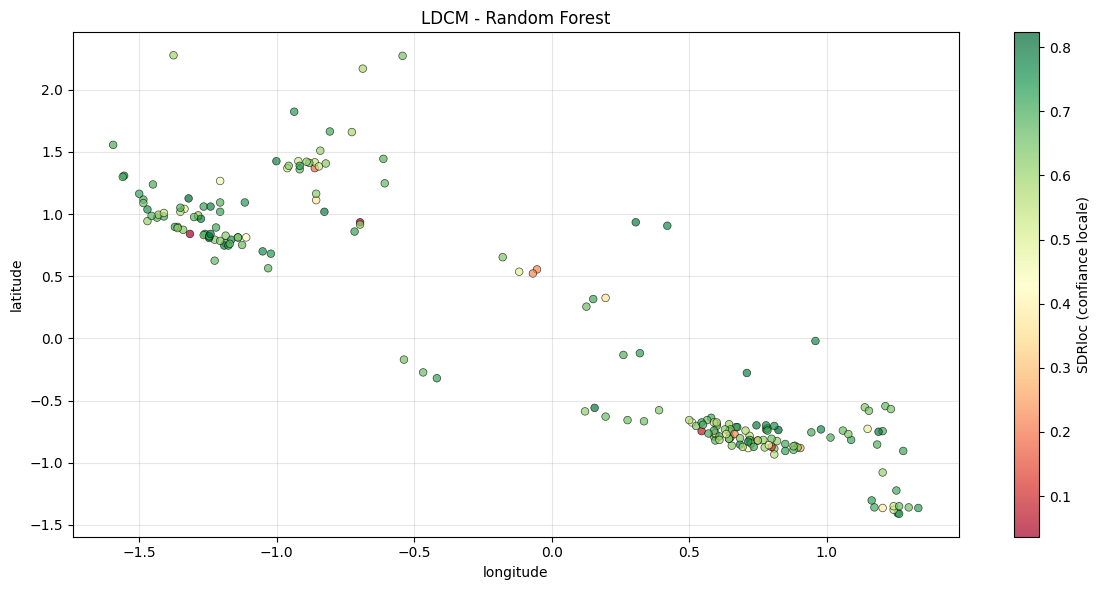

In [3]:
plt.figure(figsize=(12,6))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['SDRloc_RF'], cmap='RdYlGn', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(sc, label='SDRloc (confiance locale)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('LDCM - Random Forest')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ldcm_rf.png"), dpi=150)
plt.show()


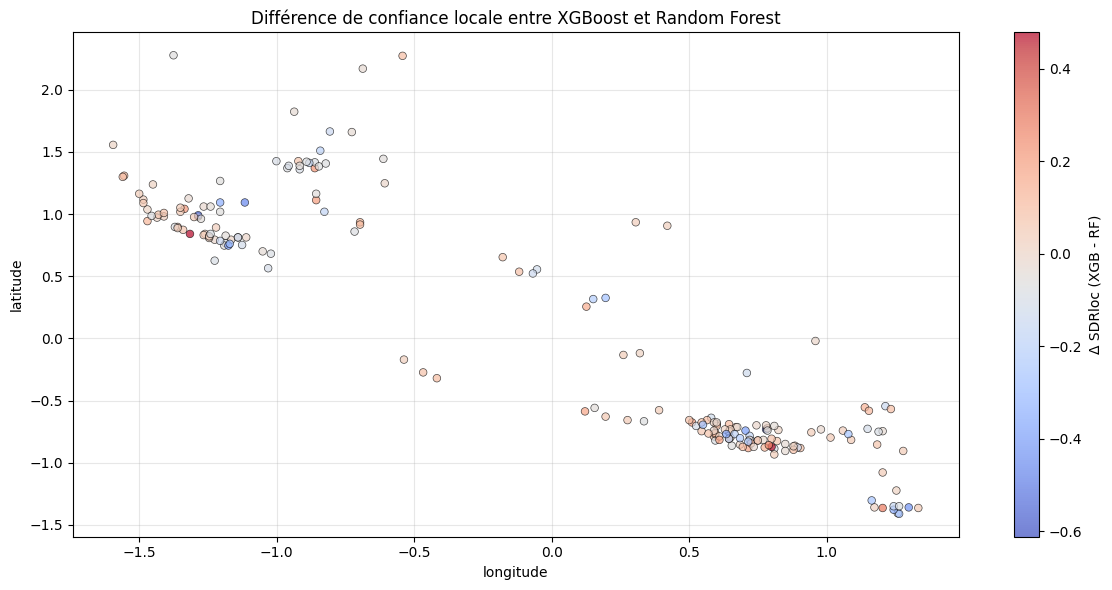

In [4]:
plt.figure(figsize=(12,6))
diff = df['SDRloc_XGB'] - df['SDRloc_RF']
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=diff, cmap='coolwarm', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(sc, label='Δ SDRloc (XGB - RF)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('Différence de confiance locale entre XGBoost et Random Forest')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ldcm_diff.png"), dpi=150)
plt.show()

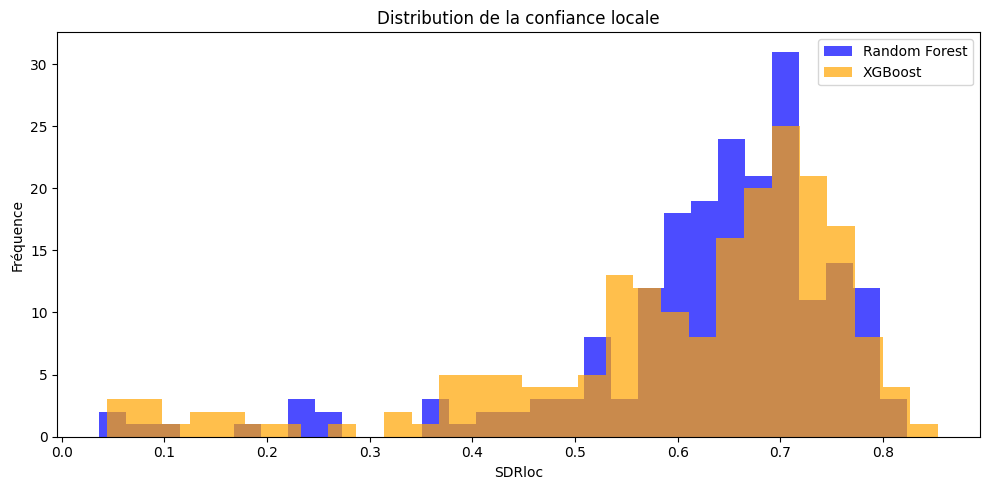

In [5]:
plt.figure(figsize=(10,5))
plt.hist(df['SDRloc_RF'], bins=30, alpha=0.7, label='Random Forest', color='blue')
plt.hist(df['SDRloc_XGB'], bins=30, alpha=0.7, label='XGBoost', color='orange')
plt.xlabel('SDRloc')
plt.ylabel('Fréquence')
plt.legend()
plt.title('Distribution de la confiance locale')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sdrloc_distribution.png"), dpi=150)
plt.show()

# 🗺️ Local Decision Confidence Maps (LDCM) – Mesure de fiabilité spatiale

---

## 1. Principe général des LDCM

Les cartes de confiance locale évaluent la fiabilité des prédictions en fonction de la position géographique $(x_i, y_i)$.

On utilise un indicateur basé sur l’accord entre deux modèles :

- $XGBoost$
- $Random\ Forest$

Plus leurs prédictions sont proches, plus la confiance est élevée.



---

## 3. Interprétation spatiale

Chaque point géographique possède une valeur SDRloc.

- $\approx 1$ : forte confiance (accord des modèles)
- $\approx 0$ : faible confiance (désaccord)

La carte colorée permet de visualiser la fiabilité spatiale.

---

## 4. Différence entre modèles

On définit :

$
\Delta \text{SDRloc}(i) = \text{SDRloc}_A(i) - \text{SDRloc}_B(i)
$

Interprétation :

- $\Delta > 0$ → modèle $A$ plus fiable
- $\Delta < 0$ → modèle $B$ plus fiable

---

## 5. Distribution des SDRloc

La distribution est donnée par :

$
\text{Freq}(x) =
\frac{1}{n} \sum_{i=1}^{n} \mathbf{1}_{\text{SDRloc}(i) \in [x, x+\Delta x]}
$

Une distribution décalée vers $1$ indique un modèle plus stable.

---

## 6. Application

Les cartes sont appliquées sur le dataset *California Housing* avec :

- XGBoost
- Random Forest

Productions :

- LDCM (XGBoost)
- LDCM (Random Forest)
- Carte $\Delta$ SDRloc
- Histogrammes comparatifs

---

## 7. Utilité

Les LDCM permettent de :

- détecter zones d’incertitude
- comparer modèles spatialement
- guider amélioration des données

---

## 8. Limites

- dépend du choix des modèles
- accord ≠ vérité
- erreurs communes peuvent masquer les problèmes

---

## Conclusion

Les LDCM offrent une vision spatiale de la confiance en combinant accord inter-modèles et analyse géographique des prédictions.
